In [4]:
#Modules

import h5py
import numpy as np
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

In [41]:
# filepaths 

filepath_200MeV = '/Users/justin/code/trajectum/cs_analysis/src/200GeV_0_800_MeVpTThresholds_SMASH.h5'

In [42]:
# data structure

# pt_bins_dir = "meanptcharged/STARTPC200MeV/centralitybinned/bin"
# pt_dbins_dir = "meanptcharged/STARTPC200MeV/centralitybinned/dbin"

meanpTcharged_values_dir = "meanptcharged/STARTPC800MeV/centralitybinned/values"
meanpTcharged_uerr_dir = "meanptcharged/STARTPC800MeV/centralitybinned/uppererrors"
meanpTcharged_lerr_dir = "meanptcharged/STARTPC800MeV/centralitybinned/lowererrors"

deltapT_valuess_dir = "ptfluctuationscharged/STARTPC800MeV/centralitybinned/values"
deltapT_uerr_dir = "ptfluctuationscharged/STARTPC800MeV/centralitybinned/uppererrors"
deltapT_lerr_dir = "ptfluctuationscharged/STARTPC800MeV/centralitybinned/lowererrors"



In [ ]:
# creating values for 

with h5py.File(filepath_200MeV, "r") as hdf:

    centrality = hdf["centrality"][:].squeeze()

    # mean pt charged 
    meanpTcharged_values = hdf[meanpTcharged_values_dir][:].squeeze()
    meanpTcharged_uerr = hdf[meanpTcharged_uerr_dir][:].squeeze()
    meanpTcharged_lerr = hdf[meanpTcharged_lerr_dir][:].squeeze()
    meanpTcharged_symerr = 0.5 * (meanpTcharged_uerr + meanpTcharged_lerr)



    # delta pt
    deltapT_values = hdf[deltapT_valuess_dir][:].squeeze() 
    deltapT_uerr = hdf[deltapT_uerr_dir][:].squeeze()
    deltapT_lerr = hdf[deltapT_lerr_dir][:].squeeze()
    deltapT_symerr = 0.5 * (deltapT_uerr + deltapT_lerr)

    # need to do propogation of error

# delta pt / mean pt charged

normalizedfluctuation = (deltapT_values / meanpTcharged_values) * 100

with np.errstate(divide='ignore', invalid='ignore'):
    ratio_err = normalizedfluctuation * np.sqrt(
        (deltapT_symerr / deltapT_values)**2 +
        (meanpTcharged_symerr / meanpTcharged_values)**2
    )



# clean any bad points (e.g., divisions by zero)
mask = np.isfinite(normalizedfluctuation) & np.isfinite(ratio_err) & (ratio_err >= 0)



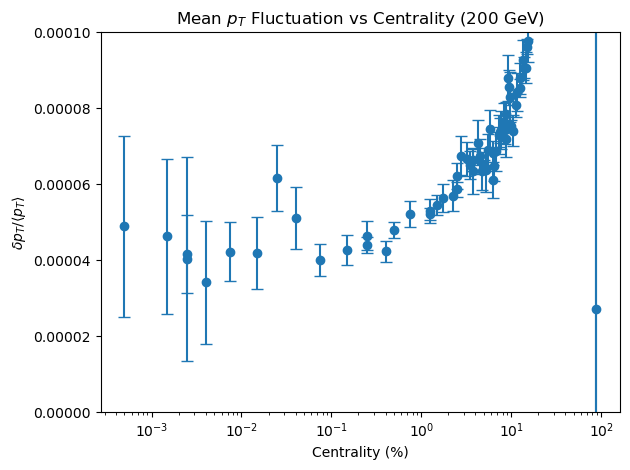

In [8]:
#plotting

plt.errorbar(
    centrality[mask],
    meanpTfluctuation[mask],
    yerr=ratio_err[mask],
    fmt="o",
    capsize=4
)

plt.xscale('log')

plt.xlabel("Centrality (%)")           # ✓ real centrality on x-axis
plt.ylabel(r"$\delta p_T / \langle p_T \rangle$")
plt.title(r"Mean $p_T$ Fluctuation vs Centrality (200 GeV)")
plt.ylim(0,0.0001)
#plt.xlim(0,5)
plt.tight_layout()
plt.show()

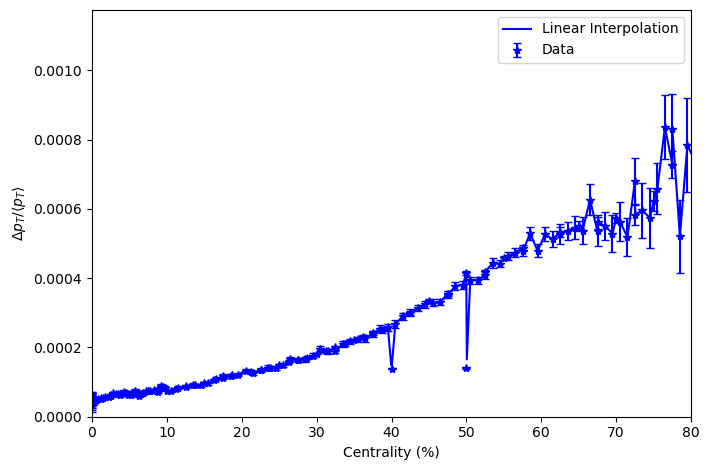

In [9]:
# assume centrality and meanptfluctuation are already 1D and masked clean
# assume centrality, meanpTfluctuation, ratio_err, mask are defined and 1D
x  = centrality[mask]
y  = meanpTfluctuation[mask]
ye = np.ravel(ratio_err[mask])   # ensure 1D yerr

# sort by x (interp1d expects monotonic x)
order = np.argsort(x)
x, y, ye = x[order], y[order], ye[order]

# linear interpolation; allow 0→80 even if outside data via extrapolation
f = interp1d(x, y, kind='linear', bounds_error=False, fill_value="extrapolate")

# explicitly enforce 0 → 80 x-axis
x_new = np.linspace(0.0, 80.0, 1000)
y_new = f(x_new)

# --- STAR-style plot with interpolation ---
plt.figure(figsize=(7.2, 4.8))
plt.errorbar(x, y, yerr=ye, fmt='*', capsize=3, label="Data",color='blue')  # star markers
plt.plot(x_new, y_new, '-', label="Linear Interpolation",color='blue')      # connecting line
plt.xlim(0, 80)
plt.ylim(0,)
plt.xlabel("Centrality (%)")
plt.ylabel(r"$\Delta p_T / \langle p_T \rangle$")
plt.legend()
plt.tight_layout()
plt.show()

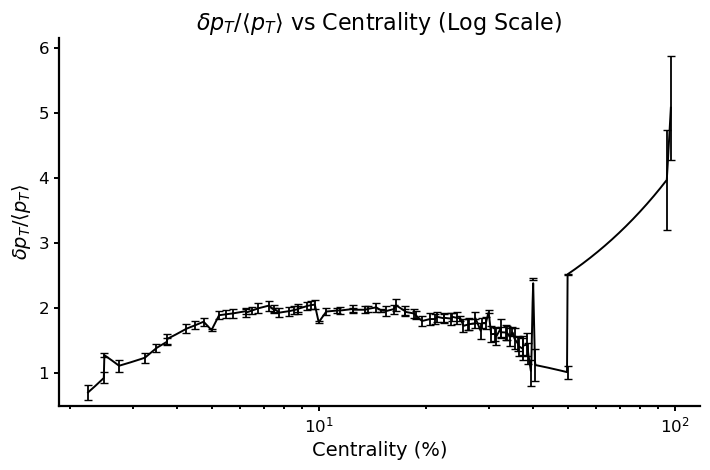

In [46]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------
# Assume:
# centrality, meanptfluctuation, ratio_err already defined
# -----------------------------------------

# mask finite + nonnegative errors
mask = (
    np.isfinite(centrality) &
    np.isfinite(normalizedfluctuation) &
    np.isfinite(ratio_err) &
    (ratio_err >= 0)
)

x = centrality[mask]
y = normalizedfluctuation[mask]
ye = ratio_err[mask]

# sort by x (interp1d requires ascending order)
order = np.argsort(x)
x = x[order]
y = y[order]
ye = ye[order]

# -----------------------------------------
# LOG SCALE REQUIRES x > 0
# So enforce that:
# -----------------------------------------
x = x[x > 0]
y = y[:len(x)]
ye = ye[:len(x)]

# linear interpolation, allow extrapolation
f = interp1d(x, y, kind='linear', bounds_error=False, fill_value="extrapolate")

# generate dense x in log space
x_new = np.logspace(np.log10(x.min()), np.log10(x.max()), 1000)
y_new = f(x_new)

# -----------------------------------------
# STAR STYLE PLOT
# -----------------------------------------
plt.figure(figsize=(7.2, 4.8))

# interpolation line (STAR uses black line)
plt.plot(x_new, y_new, '-', color='black', linewidth=1.4, label="Linear Interpolation")

# star markers + error bars (classic STAR look)
plt.errorbar(x, y, yerr=ye,
             fmt=' ', markersize=8,
             color='black', ecolor='black',
             elinewidth=1.3, capsize=3,
             label="Data")

plt.xscale("log")
plt.xlabel("Centrality (%)", fontsize=14)
plt.ylabel(r"$\delta p_T / \langle p_T \rangle$", fontsize=14)
plt.title(r"$\delta p_T / \langle p_T \rangle$ vs Centrality (Log Scale)", fontsize=16)
plt.ylim(0.5,)

# remove top + right spines (STAR style)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.6)
ax.spines['bottom'].set_linewidth(1.6)
ax.tick_params(axis='both', which='both', width=1.4, labelsize=12)

plt.tight_layout()
plt.show()
